# Govi / Emotions NLP Text Emotion Classification Notebook

This notebook is for the **Emotions NLP / Govi text dataset**.

## Includes
- Kaggle download
- extraction
- robust TXT/CSV/TSV loader
- text cleaning
- exploratory visualizations
- training and testing with:
  - TF-IDF + Logistic Regression baseline
  - BiLSTM text model
  - DistilBERT / BERT classifier
- evaluation and thesis-ready figures

In [1]:
# Install only if needed
!pip install --upgrade pip setuptools wheel
!python -m pip install kaggle torch torchaudio transformers scikit-learn pandas numpy matplotlib soundfile wordcloud
!pip install --no-cache-dir datasets accelerate
!sudo yum install -y libsndfile


  Using cached kaggle-2.0.0-py3-none-any.whl.metadata (15 kB)
  Using cached torch-2.6.0-cp312-cp312-manylinux1_x86_64.whl.metadata (28 kB)
  Using cached torchaudio-2.6.0-cp312-cp312-manylinux1_x86_64.whl.metadata (6.6 kB)
  Using cached transformers-5.5.0-py3-none-any.whl.metadata (32 kB)
  Using cached soundfile-0.13.1-py2.py3-none-any.whl.metadata (16 kB)
  Using cached wordcloud-1.9.6-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (3.4 kB)
  Using cached kagglesdk-0.1.16-py3-none-any.whl.metadata (13 kB)
  Using cached python_slugify-8.0.4-py2.py3-none-any.whl.metadata (8.5 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  U

In [2]:
import os, re, json, zipfile, random, warnings, subprocess
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cpu


In [3]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "govi_project"
RAW_DIR = DATA_DIR / "raw"
EXT_DIR = DATA_DIR / "extracted"
FIG_DIR = DATA_DIR / "figures"
CKPT_DIR = DATA_DIR / "checkpoints"

for d in [RAW_DIR, EXT_DIR, FIG_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EMOTIONS_KAGGLE_DATASET = "praveengovi/emotions-dataset-for-nlp"

def run_cmd(cmd):
    print("Running:", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"Command failed with code {result.returncode}")
    return result

def download_kaggle_dataset(dataset_slug, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    run_cmd(["kaggle", "datasets", "download", "-d", dataset_slug, "-p", str(out_dir), "--force"])

def unzip_all(zip_dir, extract_dir):
    for zf in zip_dir.glob("*.zip"):
        target = extract_dir / zf.stem
        target.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zf, "r") as z:
            z.extractall(target)
        print("Extracted:", zf.name, "->", target)

# Uncomment after Kaggle auth is configured
#download_kaggle_dataset(EMOTIONS_KAGGLE_DATASET, RAW_DIR)
#unzip_all(RAW_DIR, EXT_DIR)

In [4]:
import pandas as pd
from pathlib import Path
import re

def normalize_text(s):
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"([a-z])\1{2,}", r"\1\1", s)
    s = re.sub(r"[^a-zA-Z0-9\s']", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s
    

def parse_text_line(line: str):
    line = line.strip()
    if not line:
        return None

    if line.startswith("__label__"):
        parts = line.split(maxsplit=1)
        if len(parts) == 2:
            return parts[0].replace("__label__", "").strip(), parts[1].strip()

    for sep in ["\t", ";", ",", "|"]:
        parts = line.split(sep, 1)
        if len(parts) == 2:
            left, right = parts[0].strip(), parts[1].strip()
            if len(left) < len(right):
                return left, right
            else:
                return right, left
    return None

def load_govi_dataset(root: Path):
    rows = []

    print("Searching inside:", root)
    all_files = [p for p in root.rglob("*") if p.is_file()]
    print("Files found:", len(all_files))
    for f in all_files[:20]:
        print(" -", f)

    # 1. Try structured files first
    structured_files = list(root.rglob("*.csv")) + list(root.rglob("*.tsv")) + list(root.rglob("*.xlsx"))
    for fp in structured_files:
        try:
            if fp.suffix.lower() == ".csv":
                temp = pd.read_csv(fp)
            elif fp.suffix.lower() == ".tsv":
                temp = pd.read_csv(fp, sep="\t")
            else:
                temp = pd.read_excel(fp)

            temp.columns = [c.strip().lower() for c in temp.columns]
            text_col = next((c for c in ["text", "sentence", "utterance", "content"] if c in temp.columns), None)
            label_col = next((c for c in ["label", "emotion", "class"] if c in temp.columns), None)

            if text_col and label_col:
                for _, r in temp.iterrows():
                    rows.append({
                        "text": r[text_col],
                        "label": r[label_col],
                        "source_file": fp.name
                    })
        except Exception as e:
            print("Skipping structured file:", fp, "|", e)

    # 2. TXT fallback
    if not rows:
        txt_files = list(root.rglob("*.txt"))
        print("TXT files found:", len(txt_files))
        for fp in txt_files:
            print("Reading:", fp)
            parsed_count = 0
            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                for line in f:
                    parsed = parse_text_line(line)
                    if parsed is not None:
                        label, text = parsed
                        rows.append({
                            "text": text,
                            "label": label,
                            "source_file": fp.name
                        })
                        parsed_count += 1
            print("Parsed rows from", fp.name, ":", parsed_count)

    # 3. Force expected columns even if empty
    df = pd.DataFrame(rows, columns=["text", "label", "source_file"])

    if df.empty:
        raise ValueError(
            "No usable rows were extracted from the Govi dataset. "
            "Check the file format by printing the first few raw lines."
        )

    df["text"] = df["text"].astype(str).map(normalize_text)
    df["label"] = df["label"].astype(str).str.lower().str.strip()
    df = df[(df["text"] != "") & (df["label"] != "")].reset_index(drop=True)

    if df.empty:
        raise ValueError("Rows were found, but all became empty after cleaning.")

    return df

df = load_govi_dataset(EXT_DIR)
print(df.shape)
df.head()

Searching inside: /home/ec2-user/SageMaker/govi_project/extracted
Files found: 3
 - /home/ec2-user/SageMaker/govi_project/extracted/emotions-dataset-for-nlp/test.txt
 - /home/ec2-user/SageMaker/govi_project/extracted/emotions-dataset-for-nlp/train.txt
 - /home/ec2-user/SageMaker/govi_project/extracted/emotions-dataset-for-nlp/val.txt
TXT files found: 3
Reading: /home/ec2-user/SageMaker/govi_project/extracted/emotions-dataset-for-nlp/test.txt
Parsed rows from test.txt : 2000
Reading: /home/ec2-user/SageMaker/govi_project/extracted/emotions-dataset-for-nlp/train.txt
Parsed rows from train.txt : 16000
Reading: /home/ec2-user/SageMaker/govi_project/extracted/emotions-dataset-for-nlp/val.txt
Parsed rows from val.txt : 2000
(20000, 3)


,text,label,source_file
0,im feeling rather rotten so im not very ambiti...,sadness,test.txt
1,im updating my blog because i feel shitty,sadness,test.txt
2,i never make her separate from me because i do...,sadness,test.txt
3,i left with my bouquet of red and yellow tulip...,joy,test.txt
4,i was feeling a little vain when i did this one,sadness,test.txt


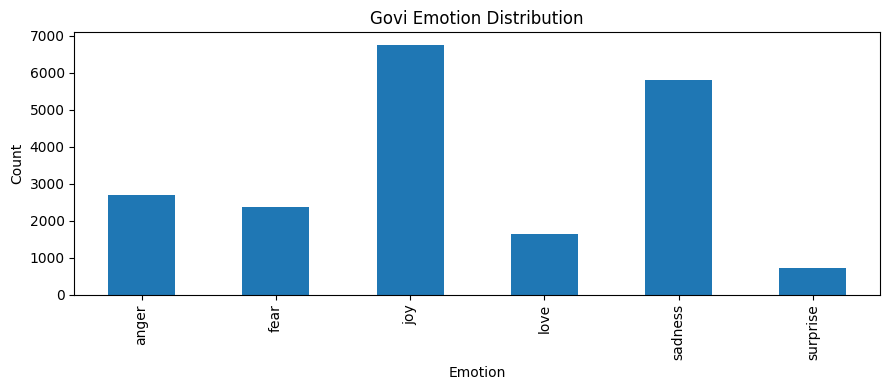

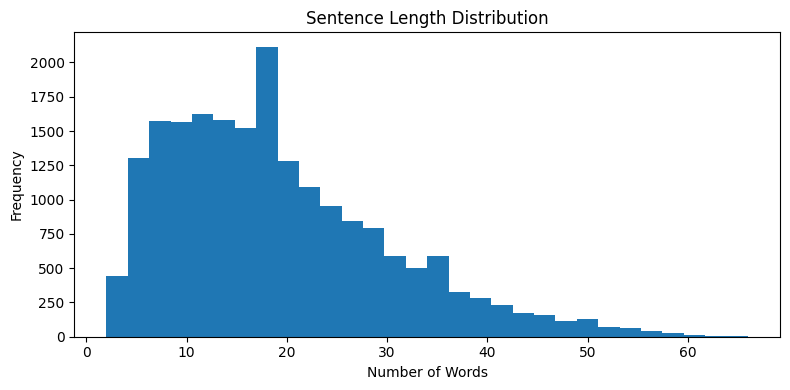

In [5]:
plt.figure(figsize=(9,4))
df["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Govi Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "govi_emotion_distribution.png", dpi=220)
plt.show()

df["text_len"] = df["text"].str.split().map(len)
plt.figure(figsize=(8,4))
plt.hist(df["text_len"], bins=30)
plt.title("Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "govi_sentence_length_distribution.png", dpi=220)
plt.show()

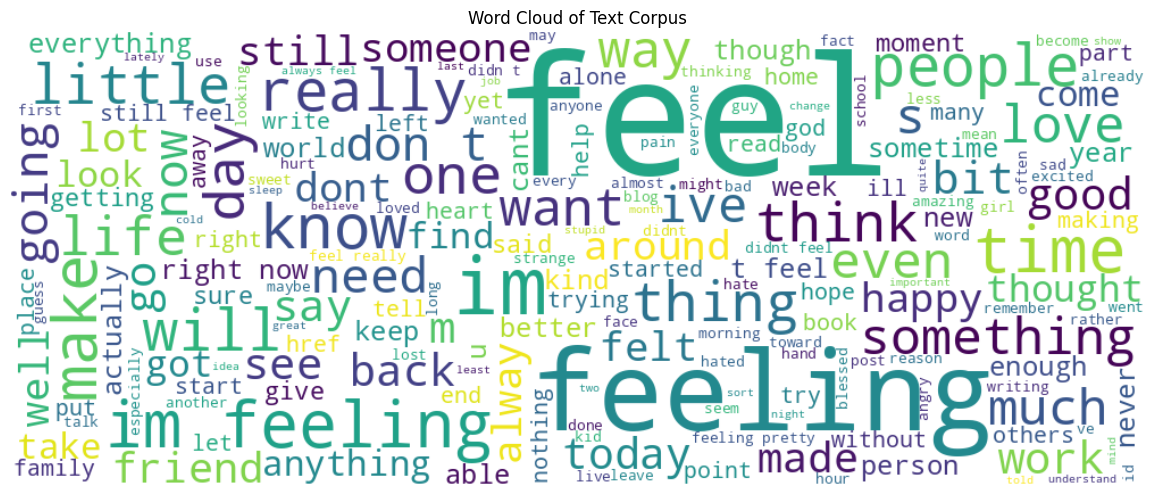

In [6]:
all_text = " ".join(df["text"].astype(str).tolist())
wordcloud = WordCloud(width=1000, height=400, background_color="white").generate(all_text)
plt.figure(figsize=(12,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Text Corpus")
plt.tight_layout()
plt.savefig(FIG_DIR / "govi_wordcloud.png", dpi=220)
plt.show()

In [7]:
label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df["label"])

train_df, test_df = train_test_split(
    df, test_size=0.15, random_state=SEED, stratify=df["label"]
)
train_df, val_df = train_test_split(
    train_df, test_size=0.1765, random_state=SEED, stratify=train_df["label"]
)
print(len(train_df), len(val_df), len(test_df), list(label_encoder.classes_))

13999 3001 3000 ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']


## Added Thesis-Aligned Visualisations

These additions fill the missing EDA / thesis visuals:
- missing-value audit
- train / validation / test composition
- text-length by emotion
- simple bivariate text-length bucket analysis
- keyword-frequency visuals aligned with feature analysis
- confusion-matrix and ROC-AUC summary plots for all text models


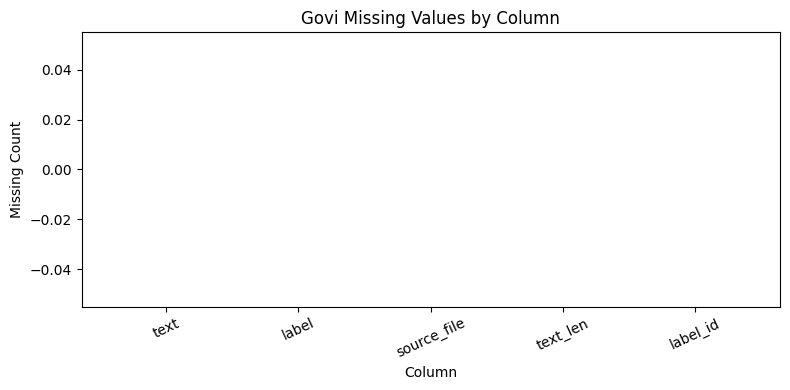

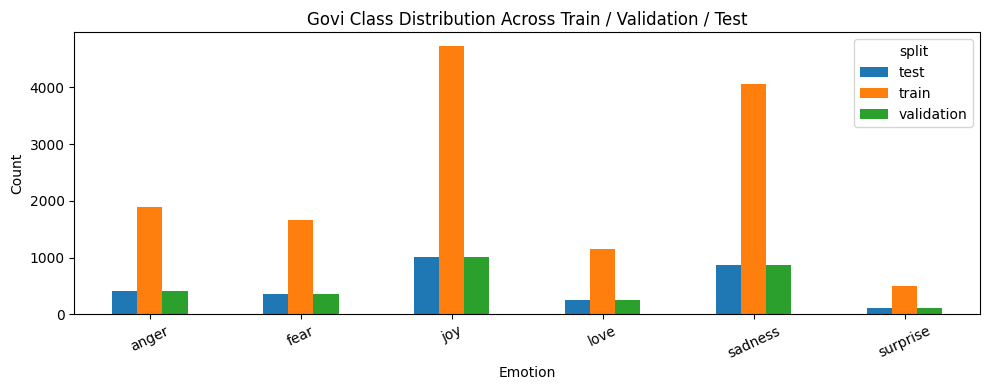

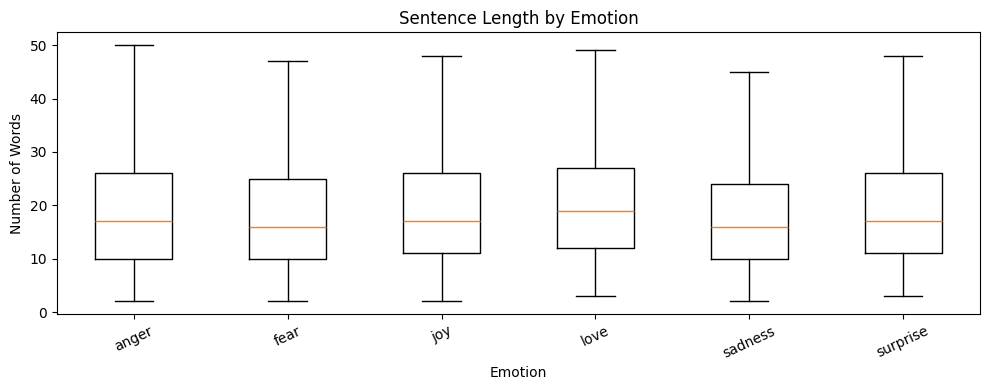

In [8]:

# =========================
# EDA: MISSING VALUES, SPLITS, TEXT LENGTH
# =========================
if len(df):
    missing_counts = df.isna().sum().sort_values(ascending=False)
    plt.figure(figsize=(8,4))
    plt.bar(missing_counts.index.astype(str), missing_counts.values)
    plt.title("Govi Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Missing Count")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "govi_missing_values.png", dpi=220)
    plt.show()

    split_plot_df = pd.concat([
        train_df.assign(split="train"),
        val_df.assign(split="validation"),
        test_df.assign(split="test")
    ], ignore_index=True)
    split_pivot = pd.crosstab(split_plot_df["label"], split_plot_df["split"])
    split_pivot.plot(kind="bar", figsize=(10,4))
    plt.title("Govi Class Distribution Across Train / Validation / Test")
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "govi_split_distribution.png", dpi=220)
    plt.show()

    grouped = [df.loc[df["label"] == lab, "text_len"].dropna().values for lab in sorted(df["label"].unique())]
    plt.figure(figsize=(10,4))
    plt.boxplot(grouped, labels=sorted(df["label"].unique()), showfliers=False)
    plt.title("Sentence Length by Emotion")
    plt.xlabel("Emotion")
    plt.ylabel("Number of Words")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "govi_text_length_by_emotion.png", dpi=220)
    plt.show()
else:
    print("Dataframe is empty.")


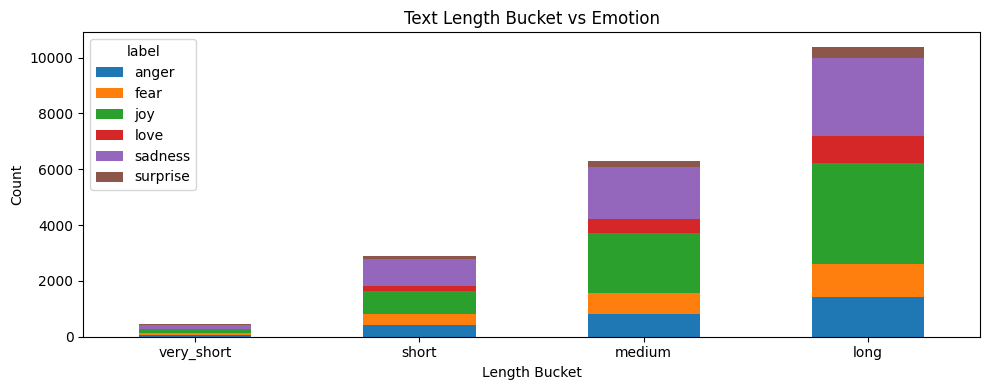

{'chi2': 138.5794120962397, 'p_value': 4.38697879313367e-22, 'dof': 15}


In [9]:

# =========================
# BIVARIATE ANALYSIS: TEXT-LENGTH BUCKET VS EMOTION
# =========================
if len(df):
    df["length_bucket"] = pd.cut(
        df["text_len"],
        bins=[-1, 4, 8, 16, 1000],
        labels=["very_short", "short", "medium", "long"]
    )

    bucket_vs_emotion = pd.crosstab(df["length_bucket"], df["label"])
    bucket_vs_emotion.plot(kind="bar", stacked=True, figsize=(10,4))
    plt.title("Text Length Bucket vs Emotion")
    plt.xlabel("Length Bucket")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "govi_length_bucket_vs_emotion.png", dpi=220)
    plt.show()

    try:
        from scipy.stats import chi2_contingency
        chi2, p_value, dof, expected = chi2_contingency(bucket_vs_emotion)
        print({"chi2": float(chi2), "p_value": float(p_value), "dof": int(dof)})
    except Exception as e:
        print("Chi-square test skipped:", e)
else:
    print("Dataframe is empty.")


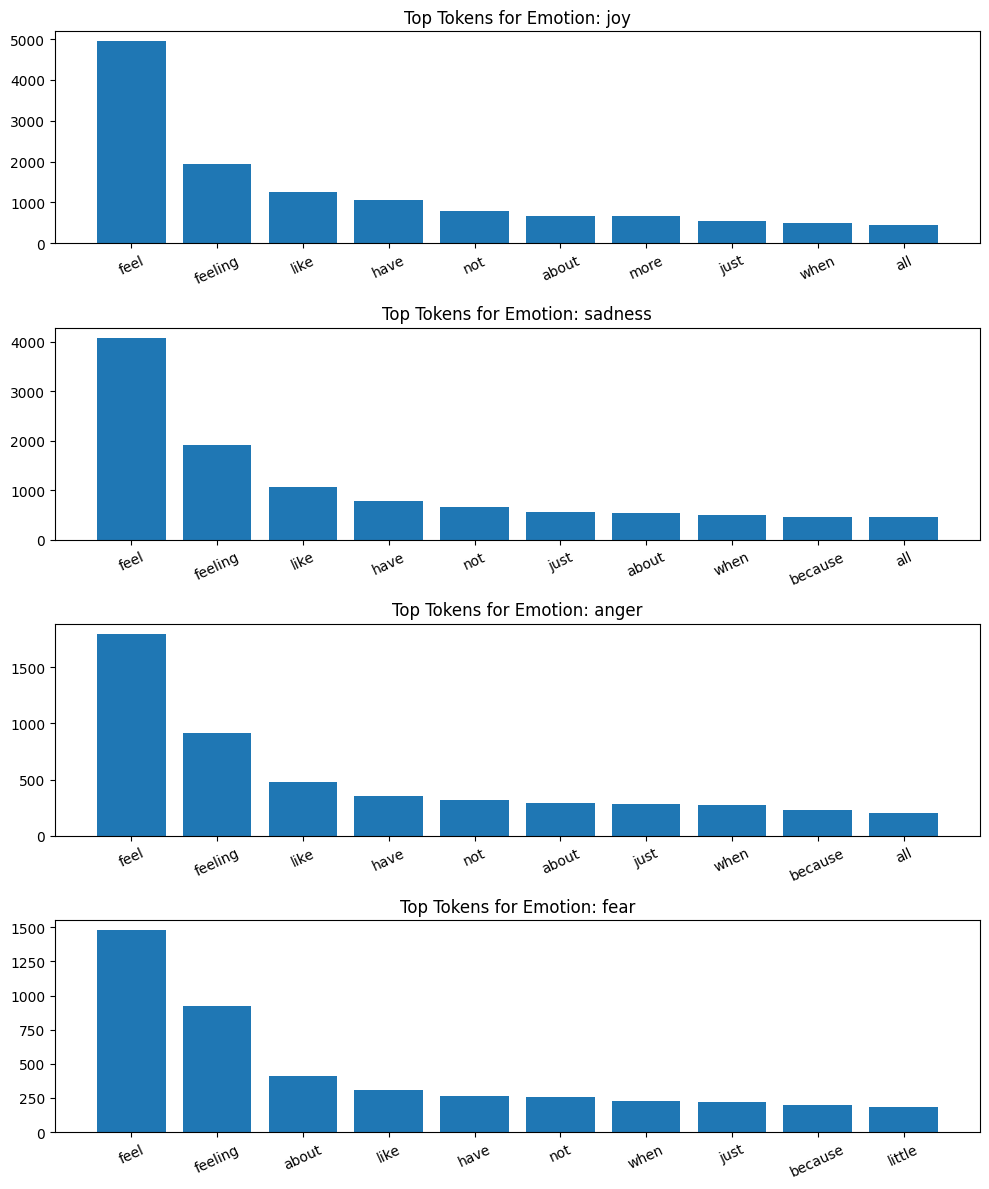

In [10]:

# =========================
# EXTRA FEATURE VISUAL: TOP KEYWORDS PER EMOTION
# =========================
from collections import Counter
import re

STOPWORDS_MINI = {
    "i", "me", "my", "we", "you", "he", "she", "it", "they",
    "a", "an", "the", "is", "am", "are", "was", "were", "be",
    "to", "of", "and", "or", "in", "on", "for", "with", "that",
    "this", "at", "as", "but", "if", "so", "very"
}

def tokenize_simple(text):
    toks = re.findall(r"[a-z']+", str(text).lower())
    return [t for t in toks if t not in STOPWORDS_MINI and len(t) > 2]

if len(df):
    top_labels = df["label"].value_counts().head(4).index.tolist()
    fig, axes = plt.subplots(len(top_labels), 1, figsize=(10, 3 * len(top_labels)))
    if len(top_labels) == 1:
        axes = [axes]
    for ax, label_name in zip(axes, top_labels):
        counter = Counter()
        subset = df.loc[df["label"] == label_name, "text"].astype(str)
        for txt in subset:
            counter.update(tokenize_simple(txt))
        top_items = counter.most_common(10)
        if top_items:
            words, counts = zip(*top_items)
            ax.bar(words, counts)
            ax.set_title(f"Top Tokens for Emotion: {label_name}")
            ax.tick_params(axis="x", rotation=25)
        else:
            ax.set_title(f"No tokens available for {label_name}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "govi_top_keywords_per_emotion.png", dpi=220)
    plt.show()
else:
    print("Dataframe is empty.")


## Model 1: TF-IDF + Logistic Regression baseline

In [11]:
vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1,2))
X_train = vectorizer.fit_transform(train_df["text"])
X_val = vectorizer.transform(val_df["text"])
X_test = vectorizer.transform(test_df["text"])

y_train = train_df["label_id"].values
y_val = val_df["label_id"].values
y_test = test_df["label_id"].values

lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)

lr_acc = accuracy_score(y_test, lr_pred)
lr_p, lr_r, lr_f1, _ = precision_recall_fscore_support(y_test, lr_pred, average="weighted", zero_division=0)
lr_auc = roc_auc_score(label_binarize(y_test, classes=list(range(len(label_encoder.classes_)))), lr_prob, multi_class="ovr")
print({"accuracy": lr_acc, "precision": lr_p, "recall": lr_r, "f1": lr_f1, "roc_auc": lr_auc})

{'accuracy': 0.8183333333333334, 'precision': 0.8329909457196212, 'recall': 0.8183333333333334, 'f1': 0.8082878054306546, 'roc_auc': 0.9835165693408369}


## Model 2: BiLSTM text classifier

In [12]:
MAX_VOCAB = 20000
MAX_LEN = 64
BATCH_SIZE = 32
EPOCHS = 6

token_counts = Counter()
for text in train_df["text"]:
    token_counts.update(text.split())

vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in token_counts.most_common(MAX_VOCAB - 2):
    vocab[word] = len(vocab)

def encode_text(text, vocab=vocab, max_len=MAX_LEN):
    ids = [vocab.get(tok, 1) for tok in text.split()]
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids = ids + [0] * (max_len - len(ids))
    return ids

class TextSeqDataset(Dataset):
    def __init__(self, frame):
        self.frame = frame.reset_index(drop=True)
    def __len__(self):
        return len(self.frame)
    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        return (
            torch.tensor(encode_text(row["text"]), dtype=torch.long),
            torch.tensor(int(row["label_id"]), dtype=torch.long)
        )

class BiLSTMTextNet(nn.Module):
    def __init__(self, vocab_size, n_classes, emb_dim=128, hidden=128):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden, batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden*2, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )
    def forward(self, x):
        x = self.emb(x)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

train_loader = DataLoader(TextSeqDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TextSeqDataset(val_df), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TextSeqDataset(test_df), batch_size=BATCH_SIZE, shuffle=False)

In [13]:
def train_text_model(model, train_loader, val_loader, ckpt_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val = float("inf")

    for epoch in range(EPOCHS):
        model.train()
        tloss, tpreds, ttrue = 0, [], []
        for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            tloss += loss.item() * yb.size(0)
            tpreds.extend(torch.argmax(logits, 1).detach().cpu().numpy())
            ttrue.extend(yb.detach().cpu().numpy())

        train_loss = tloss / len(train_loader.dataset)
        train_acc = accuracy_score(ttrue, tpreds)

        model.eval()
        vloss, vpreds, vtrue = 0, [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                vloss += loss.item() * yb.size(0)
                vpreds.extend(torch.argmax(logits, 1).cpu().numpy())
                vtrue.extend(yb.cpu().numpy())

        val_loss = vloss / len(val_loader.dataset)
        val_acc = accuracy_score(vtrue, vpreds)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), CKPT_DIR / ckpt_name)

        print(f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} train_acc={train_acc:.4f} val_acc={val_acc:.4f}")
    return history

def evaluate_torch_model(model, loader, model_name):
    model.eval()
    preds, probs, true = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            prob = torch.softmax(logits, dim=1).cpu().numpy()
            pred = np.argmax(prob, axis=1)
            probs.extend(prob)
            preds.extend(pred)
            true.extend(yb.numpy())

    acc = accuracy_score(true, preds)
    p, r, f1, _ = precision_recall_fscore_support(true, preds, average="weighted", zero_division=0)
    roc_auc = roc_auc_score(label_binarize(true, classes=list(range(len(label_encoder.classes_)))), np.array(probs), multi_class="ovr")

    cm = confusion_matrix(true, preds)
    plt.figure(figsize=(8,6))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=45)
    plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png", dpi=220)
    plt.show()

    return {"model": model_name, "accuracy": acc, "precision": p, "recall": r, "f1": f1, "roc_auc": roc_auc}

Epoch 1/6: 100%|██████████| 438/438 [00:36<00:00, 11.90it/s]


train_loss=1.5892 val_loss=1.5751 train_acc=0.3279 val_acc=0.3379


Epoch 2/6: 100%|██████████| 438/438 [00:36<00:00, 11.91it/s]


train_loss=1.5790 val_loss=1.5754 train_acc=0.3338 val_acc=0.3382


Epoch 3/6: 100%|██████████| 438/438 [00:34<00:00, 12.72it/s]


...

train_loss=1.5767 val_loss=1.5782 train_acc=0.3350 val_acc=0.3369


Epoch 5/6: 100%|██████████| 438/438 [00:35<00:00, 12.46it/s]


train_loss=1.5779 val_loss=1.5844 train_acc=0.3381 val_acc=0.3339


Epoch 6/6: 100%|██████████| 438/438 [00:37<00:00, 11.62it/s]


train_loss=1.5742 val_loss=1.5778 train_acc=0.3393 val_acc=0.3356


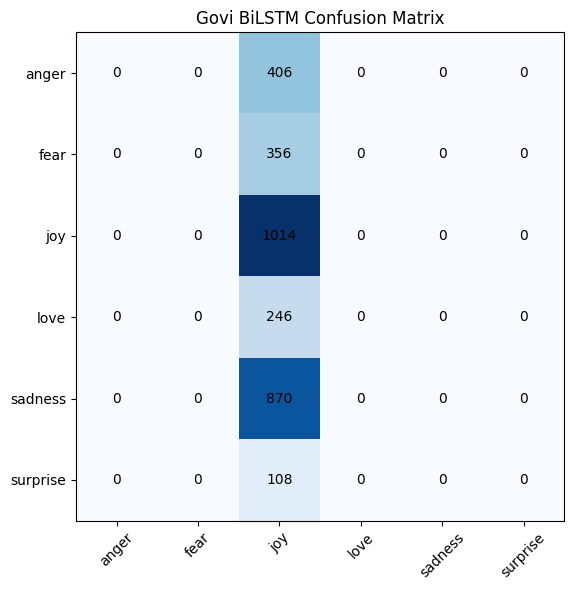

{'model': 'Govi BiLSTM',
 'accuracy': 0.338,
 'precision': 0.11424400000000001,
 'recall': 0.338,
 'f1': 0.1707683109118087,
 'roc_auc': 0.5099949460181838}

In [14]:
bilstm_model = BiLSTMTextNet(len(vocab), len(label_encoder.classes_)).to(DEVICE)
bilstm_history = train_text_model(bilstm_model, train_loader, val_loader, "govi_bilstm.pt")
bilstm_model.load_state_dict(torch.load(CKPT_DIR / "govi_bilstm.pt", map_location=DEVICE))
bilstm_results = evaluate_torch_model(bilstm_model, test_loader, "Govi BiLSTM")
bilstm_results

## Model 3: DistilBERT classifier
This is stronger for final thesis results, but heavier than the baseline models.

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

BERT_MODEL_NAME = "distilbert-base-uncased"
TOKENIZER = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

BERT_MAX_LEN = 64
BERT_BATCH = 32
BERT_EPOCHS = 2
LR = 2e-4

class BertDataset(Dataset):
    def __init__(self, frame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        enc = TOKENIZER(
            str(row["text"]),
            truncation=True,
            padding="max_length",
            max_length=BERT_MAX_LEN,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(int(row["label_id"]), dtype=torch.long)
        }

class FastDistilBERTClassifier(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(BERT_MODEL_NAME)
        hidden = self.encoder.config.hidden_size

        # Freeze almost all layers for speed
        for param in self.encoder.parameters():
            param.requires_grad = False

        # Optional: unfreeze only last transformer block for a small boost
        if hasattr(self.encoder, "transformer"):
            for param in self.encoder.transformer.layer[-1].parameters():
                param.requires_grad = True

        self.classifier = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state[:, 0, :]
        return self.classifier(pooled)

bert_train_loader = DataLoader(BertDataset(train_df), batch_size=BERT_BATCH, shuffle=True)
bert_val_loader = DataLoader(BertDataset(val_df), batch_size=BERT_BATCH, shuffle=False)
bert_test_loader = DataLoader(BertDataset(test_df), batch_size=BERT_BATCH, shuffle=False)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [16]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def train_fast_bert(model, train_loader, val_loader, ckpt_path):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR
    )

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")

    for epoch in range(BERT_EPOCHS):
        model.train()
        train_loss = 0.0
        train_preds, train_true = [], []

        for batch in tqdm(train_loader, desc=f"Fast BERT Epoch {epoch+1}/{BERT_EPOCHS}"):
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * labels.size(0)
            train_preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())
            train_true.extend(labels.detach().cpu().numpy())

        train_loss /= len(train_loader.dataset)
        train_acc = accuracy_score(train_true, train_preds)

        model.eval()
        val_loss = 0.0
        val_preds, val_true = [], []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(DEVICE)
                attention_mask = batch["attention_mask"].to(DEVICE)
                labels = batch["label"].to(DEVICE)

                logits = model(input_ids, attention_mask)
                loss = criterion(logits, labels)

                val_loss += loss.item() * labels.size(0)
                val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                val_true.extend(labels.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(val_true, val_preds)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), ckpt_path)

        print(
            f"Epoch {epoch+1}: "
            f"train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
            f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}"
        )

    return history

def evaluate_fast_bert(model, loader):
    model.eval()
    preds, probs, true = [], [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"]

            logits = model(input_ids, attention_mask)
            prob = torch.softmax(logits, dim=1).cpu().numpy()
            pred = np.argmax(prob, axis=1)

            probs.extend(prob)
            preds.extend(pred)
            true.extend(labels.numpy())

    acc = accuracy_score(true, preds)
    p, r, f1, _ = precision_recall_fscore_support(true, preds, average="weighted", zero_division=0)
    roc_auc = roc_auc_score(
        label_binarize(true, classes=list(range(len(label_encoder.classes_)))),
        np.array(probs),
        multi_class="ovr"
    )

    cm = confusion_matrix(true, preds)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title("Fast DistilBERT Confusion Matrix")
    plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=45)
    plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.show()

    return {
        "model": "Fast DistilBERT",
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
        "roc_auc": roc_auc
    }

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Fast BERT Epoch 1/2: 100%|██████████| 438/438 [16:03<00:00,  2.20s/it]


Epoch 1: train_loss=0.6631, val_loss=0.3423, train_acc=0.7646, val_acc=0.8740


Fast BERT Epoch 2/2: 100%|██████████| 438/438 [15:55<00:00,  2.18s/it]


Epoch 2: train_loss=0.3232, val_loss=0.3038, train_acc=0.8851, val_acc=0.8844


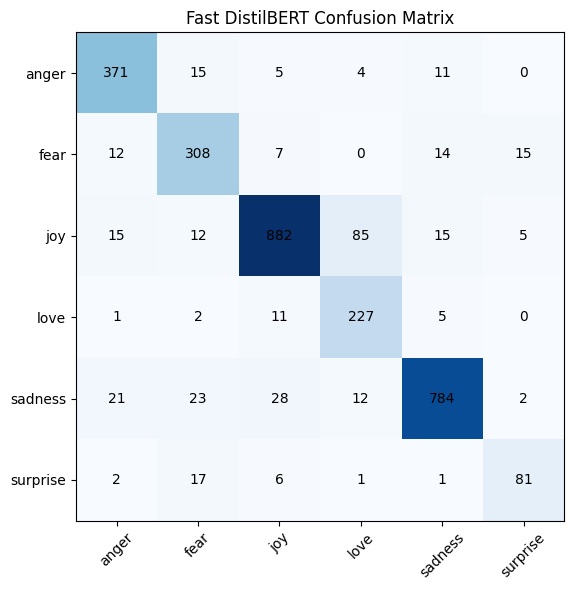

{'model': 'Fast DistilBERT',
 'accuracy': 0.8843333333333333,
 'precision': 0.8922240430406108,
 'recall': 0.8843333333333333,
 'f1': 0.8861591360945638,
 'roc_auc': 0.9886205076475741}

In [17]:
fast_bert_model = FastDistilBERTClassifier(len(label_encoder.classes_)).to(DEVICE)

fast_bert_history = train_fast_bert(
    fast_bert_model,
    bert_train_loader,
    bert_val_loader,
    CKPT_DIR / "govi_fast_distilbert.pt"
)

fast_bert_model.load_state_dict(
    torch.load(CKPT_DIR / "govi_fast_distilbert.pt", map_location=DEVICE)
)

fast_bert_results = evaluate_fast_bert(fast_bert_model, bert_test_loader)
fast_bert_results

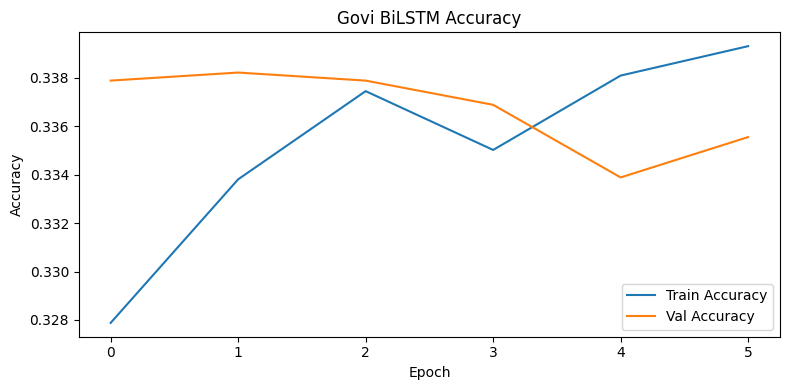

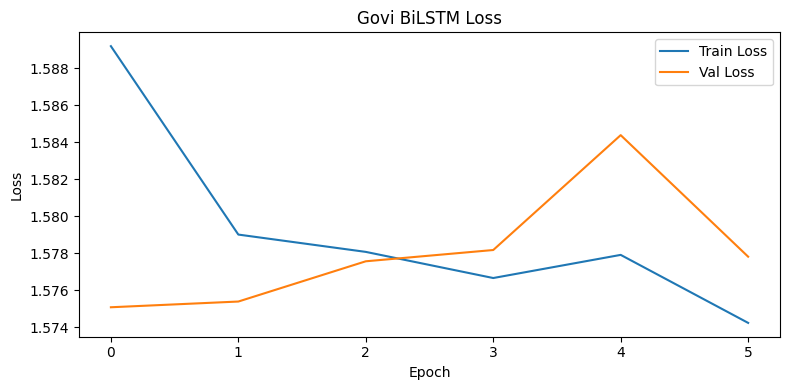

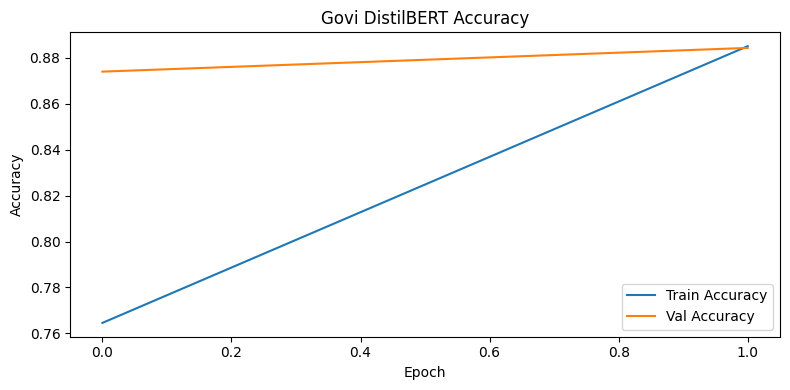

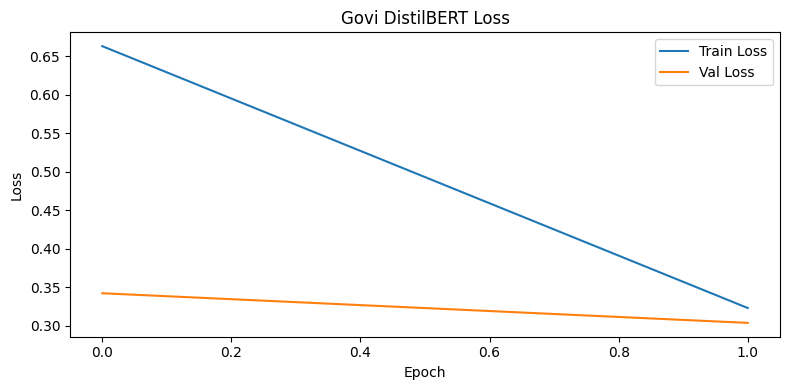

In [18]:
def plot_history(history, title_prefix, fname_prefix):
    plt.figure(figsize=(8,4))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"], label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{fname_prefix}_accuracy_curve.png", dpi=220)
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{fname_prefix}_loss_curve.png", dpi=220)
    plt.show()

plot_history(bilstm_history, "Govi BiLSTM", "govi_bilstm")
plot_history(fast_bert_history, "Govi DistilBERT", "govi_distilbert")

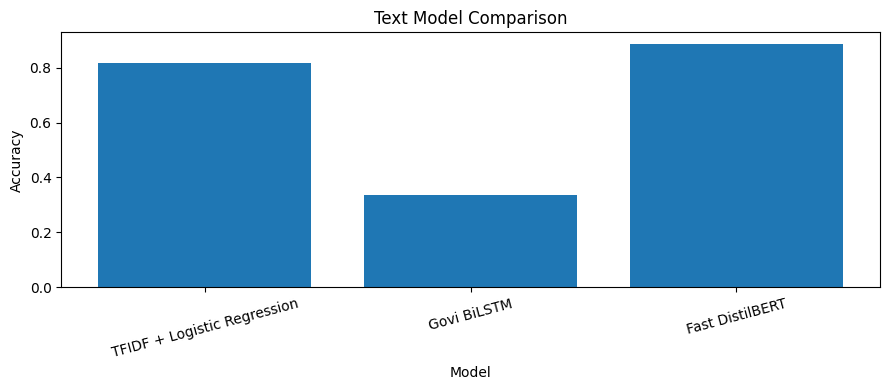

Saved figures in: /home/ec2-user/SageMaker/govi_project/figures


In [19]:
results_df = pd.DataFrame([
    {"model": "TFIDF + Logistic Regression", "accuracy": lr_acc, "precision": lr_p, "recall": lr_r, "f1": lr_f1, "roc_auc": lr_auc},
    bilstm_results,
    fast_bert_results
])
results_df

plt.figure(figsize=(9,4))
plt.bar(results_df["model"], results_df["accuracy"])
plt.title("Text Model Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "govi_model_comparison.png", dpi=220)
plt.show()

results_df.to_csv(DATA_DIR / "govi_model_results.csv", index=False)
print("Saved figures in:", FIG_DIR)

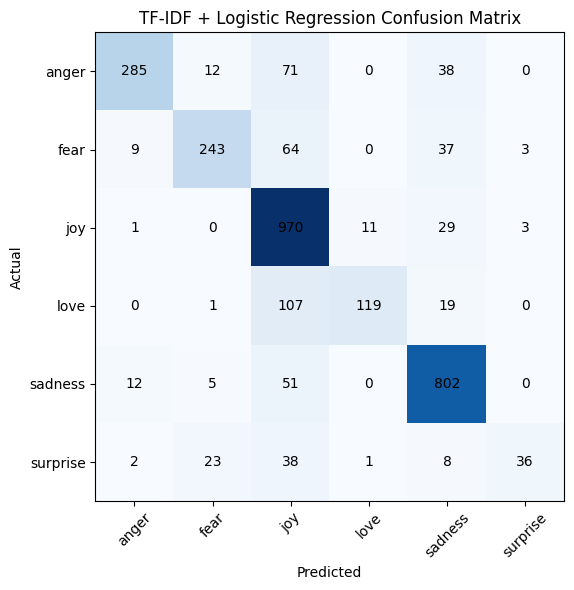

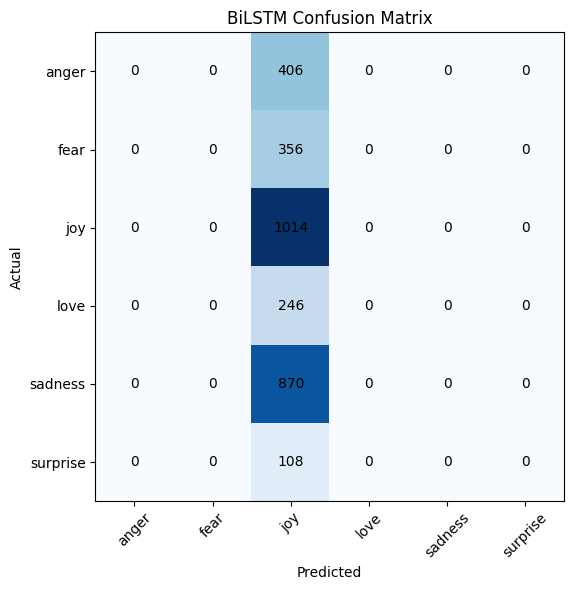

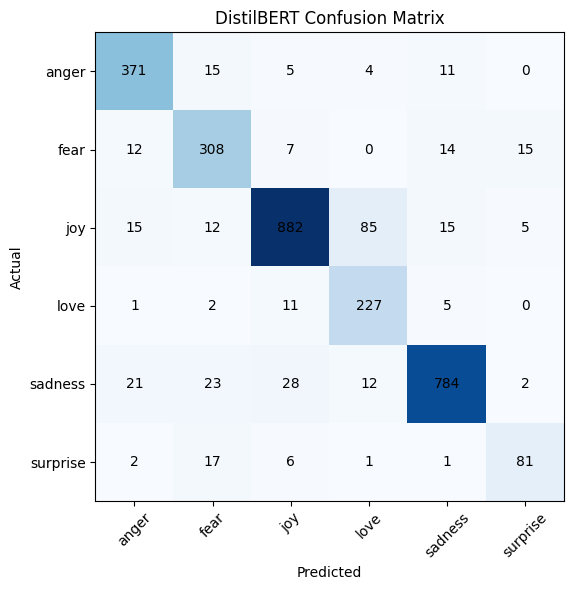

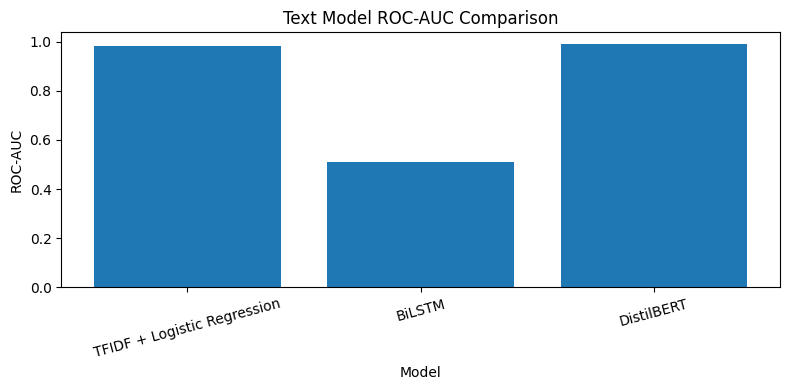

In [20]:

# =========================
# CONFUSION MATRICES + ROC-AUC SUMMARY
# =========================
def plot_confusion(true, pred, labels, title, out_name):
    cm = confusion_matrix(true, pred)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.yticks(range(len(labels)), labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(FIG_DIR / out_name, dpi=220)
    plt.show()

if len(test_df):
    # Logistic regression confusion matrix
    plot_confusion(y_test, lr_pred, list(label_encoder.classes_), "TF-IDF + Logistic Regression Confusion Matrix", "govi_lr_confusion_matrix.png")

    # BiLSTM predictions for combined comparison
    bilstm_model.eval()
    bilstm_preds, bilstm_probs, bilstm_true = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            logits = bilstm_model(xb)
            prob = torch.softmax(logits, dim=1).cpu().numpy()
            bilstm_probs.extend(prob)
            bilstm_preds.extend(np.argmax(prob, axis=1))
            bilstm_true.extend(yb.numpy())
    plot_confusion(bilstm_true, bilstm_preds, list(label_encoder.classes_), "BiLSTM Confusion Matrix", "govi_bilstm_confusion_matrix_extra.png")

    # DistilBERT predictions for combined comparison
    fast_bert_model.eval()
    bert_preds, bert_probs, bert_true = [], [], []
    with torch.no_grad():
        for batch in bert_test_loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"]
            logits = fast_bert_model(input_ids, attention_mask)
            prob = torch.softmax(logits, dim=1).cpu().numpy()
            bert_probs.extend(prob)
            bert_preds.extend(np.argmax(prob, axis=1))
            bert_true.extend(labels.numpy())
    plot_confusion(bert_true, bert_preds, list(label_encoder.classes_), "DistilBERT Confusion Matrix", "govi_distilbert_confusion_matrix_extra.png")

    roc_summary = pd.DataFrame([
        {"model": "TFIDF + Logistic Regression", "roc_auc": lr_auc},
        {"model": "BiLSTM", "roc_auc": bilstm_results["roc_auc"]},
        {"model": "DistilBERT", "roc_auc": fast_bert_results["roc_auc"]},
    ])
    plt.figure(figsize=(8,4))
    plt.bar(roc_summary["model"], roc_summary["roc_auc"])
    plt.title("Text Model ROC-AUC Comparison")
    plt.xlabel("Model")
    plt.ylabel("ROC-AUC")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "govi_roc_auc_comparison.png", dpi=220)
    plt.show()
else:
    print("Test data unavailable.")
